In [1]:
JSON_PATH = "./json/twist/close_60.json"

In [2]:
from src.json_to_pose.base import Pose, PoseAnalyzer
from src.json_to_pose.values import blazepose_lines
import src.utils.plot_painter as plot_painter
from src.utils.process_data import kpt_pos_to_plot_pos
import matplotlib.pyplot as plt

# 參考類型
from mpl_toolkits.mplot3d import Axes3D

In [3]:
pose = Pose(JSON_PATH)
analyzer = PoseAnalyzer(pose)
angles = analyzer.get_all_pose_shoulder_hip_staggered_angle(True)

In [4]:
max_angle_val = max(angles)
max_angle_idx = angles.index(max(angles))
min_angle_idx = angles.index(min(angles))

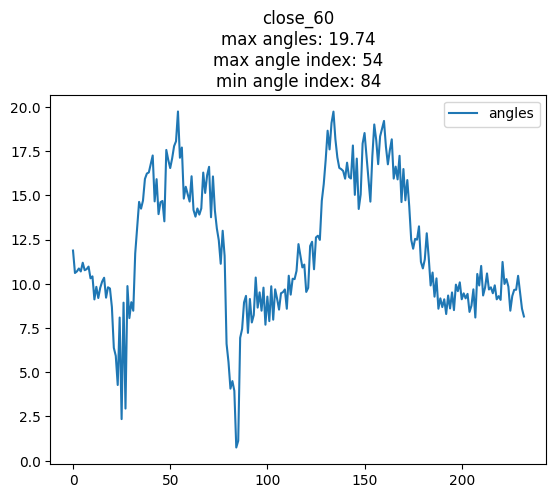

In [5]:
title = "close_60\n"
title += f"max angles: {max_angle_val:.2f}\n"
title += f"max angle index: {max_angle_idx}\n"
title += f"min angle index: {min_angle_idx}"

fig = plt.figure()
ax = fig.add_subplot()
ax.set_title(title)

ax.plot(range(len(angles)), angles, label="angles")
ax.legend()

plt.show()

In [6]:
# 顯示資料範圍
data_range_x = [-1, 1]  # x 軸
data_range_y = [-1, 1]  # y 軸
data_range_z = [0, 2]  # z 軸

# 圖表資訊顏色
c_left = "#f00"  # 左邊
c_center = "#0f0"  # 中間
c_right = "#00f"  # 右邊
c_dot = "#000"  # 關鍵點

is_3d = True  # 圖表是否為 3D
dot_size = 5  # 繪製關鍵點大小
line_lst = blazepose_lines  # 設定連線列表

elev, azim, roll = 30, 270, 0  # 右邊視角

In [7]:
# 取得最大和最小角度姿勢的關鍵點列表
kpt_list_for_max_angle = pose.get_pose_kpt_positions(max_angle_idx, 0, is_3d)
kpt_list_for_min_angle = pose.get_pose_kpt_positions(min_angle_idx, 0, is_3d)

# 取得最大和最小角度姿勢的身體線條列表
pose_lines_for_max_angle = analyzer.get_pose_line_postions(
    max_angle_idx, 0, blazepose_lines, is_3d
)
pose_lines_for_min_angle = analyzer.get_pose_line_postions(
    min_angle_idx, 0, blazepose_lines, is_3d
)

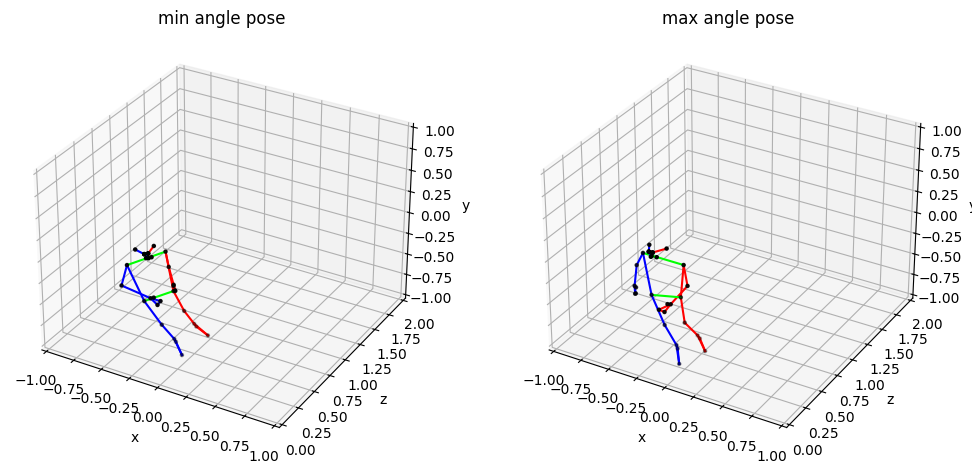

In [10]:
fig = plt.figure(figsize=(12, 6))

### 繪製肩臀最小角度的姿勢狀態

ax_0: Axes3D = fig.add_subplot(121, projection="3d")
ax_0.set_title("min angle pose")
# ax_0.view_init(elev, azim, roll)
plot_painter.set_data_range(data_range_x, data_range_z, data_range_y, ax_0)
# 將關鍵點座標轉換成圖表座標
left, center, right = pose_lines_for_min_angle
left = kpt_pos_to_plot_pos(left)
center = kpt_pos_to_plot_pos(center)
right = kpt_pos_to_plot_pos(right)
kpt = kpt_pos_to_plot_pos(kpt_list_for_min_angle)
# 進行繪製
plot_painter.draw_dots(kpt, is_3d, dot_size, c_dot, "kpt", ax_0)
plot_painter.draw_lines(left, is_3d, c_left, ax_0)
plot_painter.draw_lines(center, is_3d, c_center, ax_0)
plot_painter.draw_lines(right, is_3d, c_right, ax_0)

### 繪製肩臀最大角度的姿勢狀態
ax_1: Axes3D = fig.add_subplot(122, projection="3d")
ax_1.set_title("max angle pose")
# ax_1.view_init(elev, azim, roll)
plot_painter.set_data_range(data_range_x, data_range_z, data_range_y, ax_1)
# 將關鍵點座標轉換成圖表座標
left, center, right = pose_lines_for_max_angle
left = kpt_pos_to_plot_pos(left)
center = kpt_pos_to_plot_pos(center)
right = kpt_pos_to_plot_pos(right)
kpt = kpt_pos_to_plot_pos(kpt_list_for_max_angle)
# 進行繪製
plot_painter.draw_dots(kpt, is_3d, dot_size, c_dot, "kpt", ax_1)
plot_painter.draw_lines(left, is_3d, c_left, ax_1)
plot_painter.draw_lines(center, is_3d, c_center, ax_1)
plot_painter.draw_lines(right, is_3d, c_right, ax_1)

plt.show()